#  Análise Exploratória: Mortes e Violências contra LGBTI+ no Brasil (2021–2024)

## 0. Setup

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import geopandas as gpd
import requests
warnings.filterwarnings('ignore')

# Estilo
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 60)

## 1. Carregamento e unificação das bases

In [2]:
BASE_DIR = 'C:/Users/gabri/OneDrive/Desktop/observatorio/'

arquivos = {
    2021: BASE_DIR + 'Registro de Mortes Violentas de LGBTI+ no Brasil - 2021 - Registros.csv',
    2022: BASE_DIR + 'Sistematizaçao das Mortes e Violências contra LGBTI+ no Brasil - 2022 - Registros.csv',
    2023: BASE_DIR + 'Sistematização das Mortes e Violências contra LGBTI+ no Brasil - 2023 - Registros Final.csv',
    2024: BASE_DIR + 'Sistematizaçao das Mortes e Violências contra LGBTI+ no Brasil - 2024 - Antra 2024.csv',
}

RENAME = {
    'MACRORREGIÃO': 'REGIÃO',
    'MACROREGIÃO': 'REGIÃO',
    'COR/RAÇA': 'RAÇA/ETNIA',
    'Justificativa': 'JUSTIFICATIVA DO QUALIFICADOR',
}

dfs = []
for ano, caminho in arquivos.items():
    df = pd.read_csv(caminho, encoding='utf-8', low_memory=False, dtype=str)
    df = df.rename(columns=RENAME)
    df.insert(0, 'ANO', str(ano))
    dfs.append(df)

base = pd.concat(dfs, ignore_index=True, sort=False)
print(f'Base unificada: {base.shape[0]} registros | {base.shape[1]} colunas')

Base unificada: 861 registros | 52 colunas


## 2. Limpeza e padronização

In [3]:
# Padroniza valores N.I (não informado)
def normaliza_ni(s):
    if pd.isna(s): return 'N.I.'
    s = str(s).strip()
    if s.upper() in ['N.I.', 'N.I', 'NI', 'N/I', '']: return 'N.I.'
    return s

colunas_categoricas = [
    'UF', 'LOCAL', 'ESPAÇO', 'PERÍODO (matutino, vespertino e noturno)',
    'ORIENTAÇÃO SEXUAL', 'IDENTIDADE DE GÊNERO', 'SEGMENTO',
    'RAÇA/ETNIA', 'PROFISSÃO/OCUPAÇÃO DA VÍTIMA', 'TIPIFICAÇÃO'
]

for col in colunas_categoricas:
    if col in base.columns:
        base[col] = base[col].apply(normaliza_ni).str.strip().str.title()

# Padroniza UF (alguns anos usam nome completo, outros sigla)
uf_map = {
    'São Paulo': 'SP', 'Rio De Janeiro': 'RJ', 'Minas Gerais': 'MG',
    'Bahia': 'BA', 'Ceará': 'CE', 'Pernambuco': 'PE', 'Paraná': 'PR',
    'Rio Grande Do Sul': 'RS', 'Goiás': 'GO', 'Maranhão': 'MA',
    'Pará': 'PA', 'Amazonas': 'AM', 'Mato Grosso': 'MT',
    'Mato Grosso Do Sul': 'MS', 'Espírito Santo': 'ES',
    'Rio Grande Do Norte': 'RN', 'Paraíba': 'PB', 'Alagoas': 'AL',
    'Sergipe': 'SE', 'Piauí': 'PI', 'Tocantins': 'TO',
    'Rondônia': 'RO', 'Acre': 'AC', 'Amapá': 'AP', 'Roraima': 'RR',
    'Santa Catarina': 'SC', 'Distrito Federal': 'DF',
}
base['UF'] = base['UF'].replace(uf_map)

# Normaliza ESPAÇO
base['ESPAÇO'] = base['ESPAÇO'].replace({
    'Espaço Público': 'Público', 'Espaço Privado': 'Privado',
    'Espaco Público': 'Público', 'Espaco Privado': 'Privado',
    'Espaço público': 'Público', 'Espaço Privado': 'Privado',
})

# Limpa TIPIFICAÇÃO
base['TIPIFICAÇÃO'] = base['TIPIFICAÇÃO'].replace({
    'Homicídio': 'Homicídio', 'Homicidio': 'Homicídio',
    'Suicídio': 'Suicídio', 'Suicidio': 'Suicídio',
})

# IDADE numérica
base['IDADE_NUM'] = pd.to_numeric(base['IDADE'], errors='coerce')

# DATA MORTE
base['DATA MORTE'] = pd.to_datetime(base['DATA MORTE'], dayfirst=True, errors='coerce')
base['MÊS_NUM'] = base['DATA MORTE'].dt.month

print('Limpeza concluída.')
base[colunas_categoricas].head(3)

Limpeza concluída.


,UF,LOCAL,ESPAÇO,"PERÍODO (matutino, vespertino e noturno)",ORIENTAÇÃO SEXUAL,IDENTIDADE DE GÊNERO,SEGMENTO,RAÇA/ETNIA,PROFISSÃO/OCUPAÇÃO DA VÍTIMA,TIPIFICAÇÃO
0,Ac,Residência Da Vítima,Privado,N.I.,N.I.,Mulher Trans,Mulher Trans,Preta,N.I.,Suicídio
1,Al,Praça,Público,Noturno,Gay,Homem Cis,Gay,Preta,Cantor,Homicídio
2,Al,Casa,Privado,N.I.,Gay,Homem Cis,Gay,Preta,Empresário,Homicídio


## 3. Visão geral

In [9]:
print('=== Registros por ano ===')
print(base['ANO'].value_counts().sort_index().to_frame('registros'))

print('\n=== Missing values nas colunas principais ===')
miss = base[colunas_categoricas + ['IDADE_NUM']].apply(
    lambda c: (c == 'N.I.' if c.dtype == object else c.isna()).sum()
)
miss_pct = (miss / len(base) * 100).round(1)
print(pd.DataFrame({'N.I. / NaN': miss, '%': miss_pct}))

=== Registros por ano ===
      registros
ANO            
2021        316
2022        273
2023        230
2024         42

=== Missing values nas colunas principais ===
                                          N.I. / NaN     %
UF                                                 0   0.0
LOCAL                                              0   0.0
ESPAÇO                                             0   0.0
PERÍODO (matutino, vespertino e noturno)           0   0.0
ORIENTAÇÃO SEXUAL                                  0   0.0
IDENTIDADE DE GÊNERO                               0   0.0
SEGMENTO                                           0   0.0
RAÇA/ETNIA                                         0   0.0
PROFISSÃO/OCUPAÇÃO DA VÍTIMA                       0   0.0
TIPIFICAÇÃO                                        0   0.0
IDADE_NUM                                        185  21.5


## 4. Evolução anual

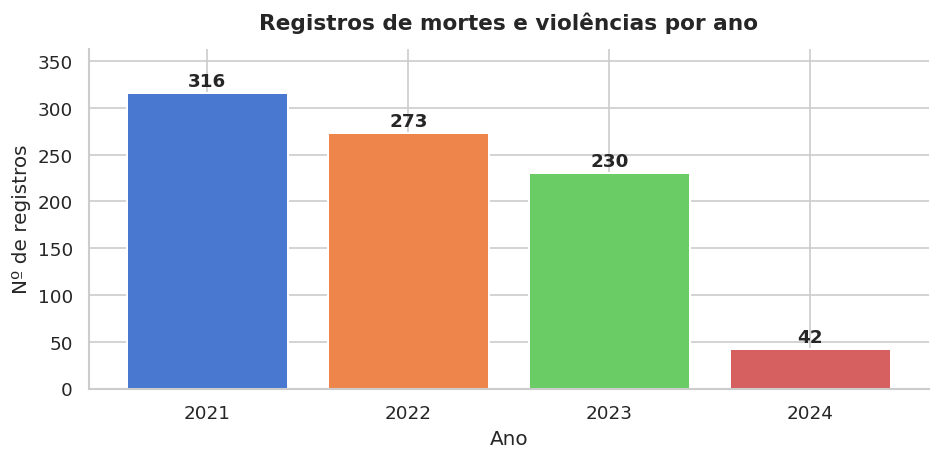

In [10]:
por_ano = base['ANO'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(por_ano.index, por_ano.values, color=sns.color_palette('muted', 4), edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, por_ano.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3, str(val),
            ha='center', va='bottom', fontweight='bold', fontsize=11)
ax.set_title('Registros de mortes e violências por ano', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Ano')
ax.set_ylabel('Nº de registros')
ax.set_ylim(0, por_ano.max() * 1.15)
sns.despine()
plt.tight_layout()
plt.show()

## 5. Distribuição por UF (Top 15)

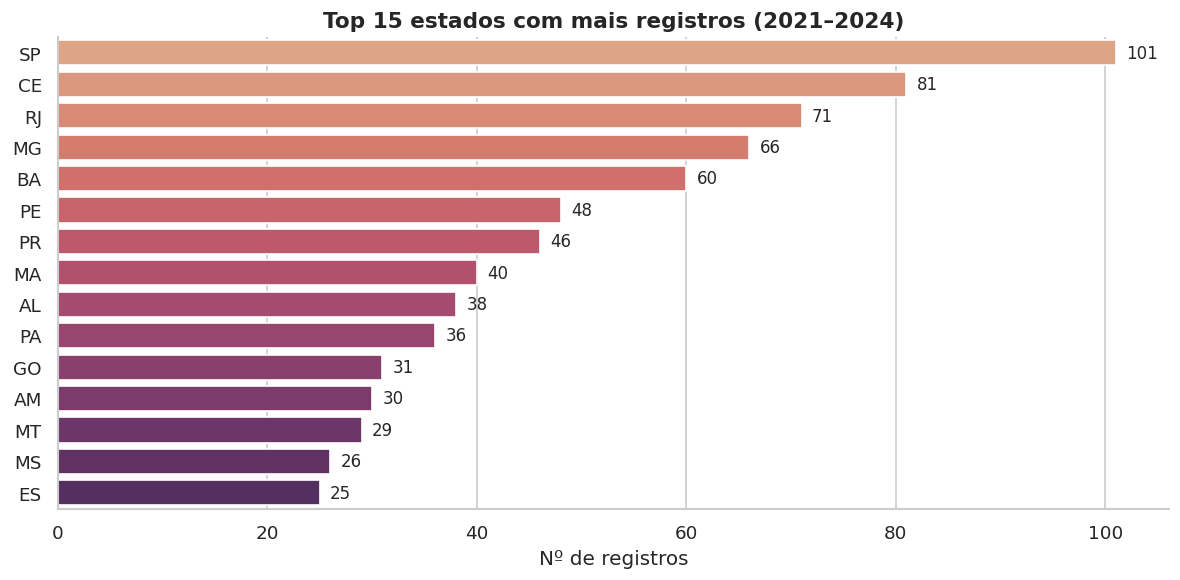

In [4]:
import pandas as pd

# Mapeamento nome por extenso → sigla
uf_map = {
    'Acre': 'AC', 'Alagoas': 'AL', 'Amapá': 'AP', 'Amazonas': 'AM',
    'Bahia': 'BA', 'Ceará': 'CE', 'Distrito Federal': 'DF',
    'Espírito Santo': 'ES', 'Goiás': 'GO', 'Maranhão': 'MA',
    'Mato Grosso': 'MT', 'Mato Grosso do Sul': 'MS', 'Minas Gerais': 'MG',
    'Pará': 'PA', 'Paraíba': 'PB', 'Paraná': 'PR', 'Pernambuco': 'PE',
    'Piauí': 'PI', 'Rio de Janeiro': 'RJ', 'Rio Grande do Norte': 'RN',
    'Rio Grande do Sul': 'RS', 'Rondônia': 'RO', 'Roraima': 'RR',
    'Santa Catarina': 'SC', 'São Paulo': 'SP', 'Sergipe': 'SE',
    'Tocantins': 'TO',
}

base['UF'] = (
    base['UF']
    .str.strip()                          # remove espaços extras
    .str.upper()                          # padroniza capitalização (sp → SP)
    .replace({k.upper(): v for k, v in uf_map.items()})  # nome → sigla
    .replace({'N.I': pd.NA, 'N.I.': pd.NA})              # remove "não identificado"
)

top_uf = base['UF'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=top_uf.values, y=top_uf.index, palette='flare', ax=ax)
for i, v in enumerate(top_uf.values):
    ax.text(v + 1, i, str(v), va='center', fontsize=10)
ax.set_title('Top 15 estados com mais registros (2021–2024)', fontsize=13, fontweight='bold')
ax.set_xlabel('Nº de registros')
ax.set_ylabel('')
sns.despine()
plt.tight_layout()
plt.show()

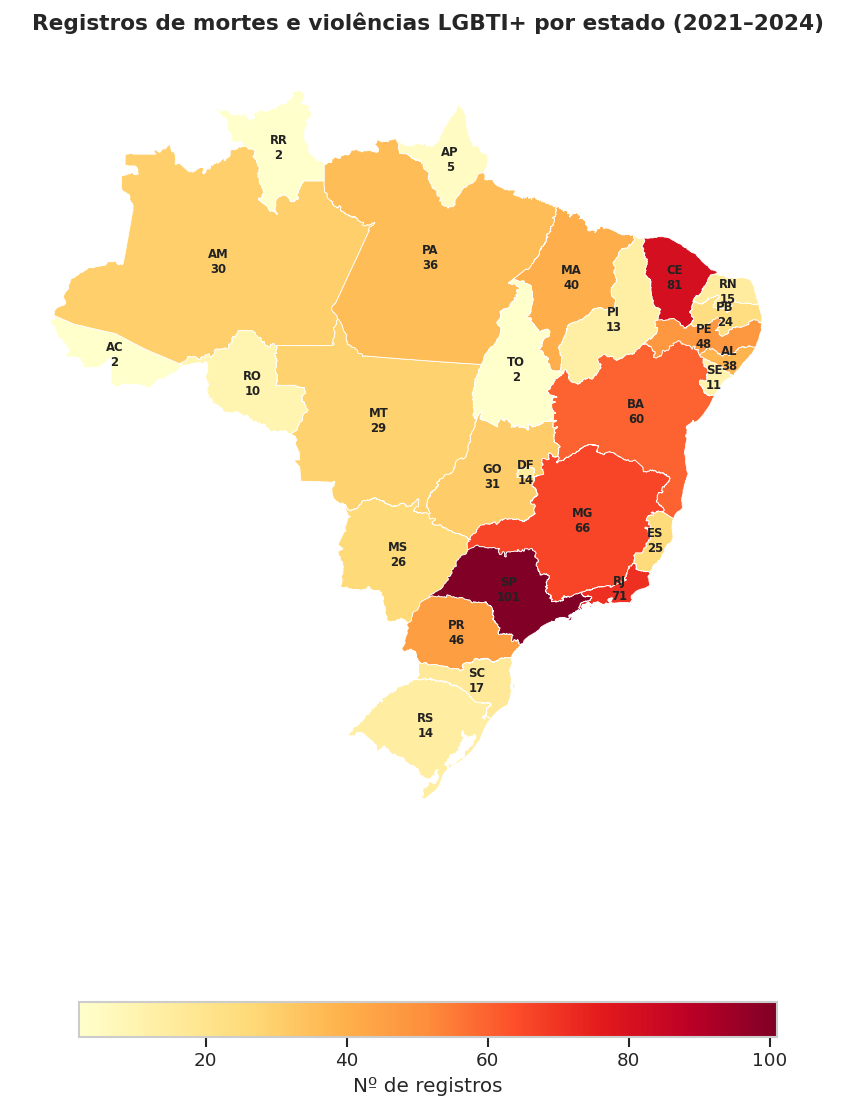

In [ ]:
uf_map = {
    'ACRE':'AC','ALAGOAS':'AL','AMAPÁ':'AP','AMAZONAS':'AM','BAHIA':'BA',
    'CEARÁ':'CE','DISTRITO FEDERAL':'DF','ESPÍRITO SANTO':'ES','GOIÁS':'GO',
    'MARANHÃO':'MA','MATO GROSSO':'MT','MATO GROSSO DO SUL':'MS',
    'MINAS GERAIS':'MG','PARÁ':'PA','PARAÍBA':'PB','PARANÁ':'PR',
    'PERNAMBUCO':'PE','PIAUÍ':'PI','RIO DE JANEIRO':'RJ',
    'RIO GRANDE DO NORTE':'RN','RIO GRANDE DO SUL':'RS','RONDÔNIA':'RO',
    'RORAIMA':'RR','SANTA CATARINA':'SC','SÃO PAULO':'SP','SERGIPE':'SE',
    'TOCANTINS':'TO',
}

base['UF_NORM'] = (
    base['UF'].str.strip().str.upper()
    .map(lambda x: uf_map.get(x, x))
    .replace({'N.I': pd.NA, 'N.I.': pd.NA})
)

contagem = base['UF_NORM'].value_counts().reset_index()
contagem.columns = ['sigla', 'registros']  # ← já usa 'sigla' para bater com o GeoJSON

# GeoJSON com sigla pronta
url = 'https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson'
gdf = gpd.GeoDataFrame.from_features(requests.get(url).json()['features'])
gdf['sigla'] = gdf['sigla'].str.strip().str.upper()

# Merge direto — sem mapeamento de código
gdf = gdf.merge(contagem, on='sigla', how='left')
gdf['registros'] = gdf['registros'].fillna(0)

# Plot
fig, ax = plt.subplots(figsize=(12, 10))
gdf.plot(
    column='registros', cmap='YlOrRd', linewidth=0.5, edgecolor='white',
    legend=True,
    legend_kwds={'label': 'Nº de registros', 'orientation': 'horizontal', 'shrink': 0.5},
    ax=ax,
)
for _, row in gdf.iterrows():
    if row.geometry:
        x, y = row.geometry.centroid.x, row.geometry.centroid.y
        ax.annotate(
            f"{row['sigla']}\n{int(row['registros'])}",
            xy=(x, y), ha='center', va='center',
            fontsize=7, color='#222222', fontweight='bold'
        )
ax.set_title('Registros de mortes e violências LGBTI+ por estado (2021–2024)',
             fontsize=13, fontweight='bold', pad=15)
ax.axis('off')
plt.tight_layout()
plt.show()

## 6. Local e espaço da ocorrência

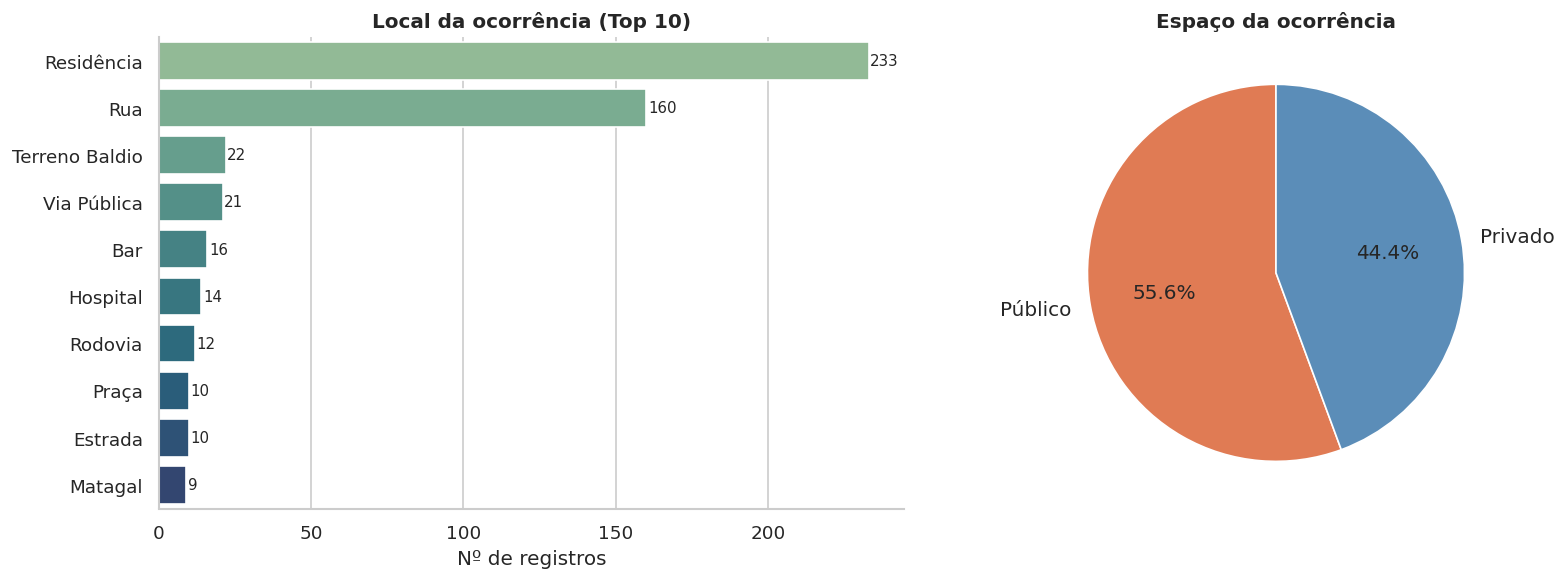

In [5]:
# Normalização do LOCAL: agrupa variações de "residência"
local_map = {
    r'(?i)^casa$': 'Residência',
    r'(?i)casa\s*da\s*v[ií]tima': 'Residência',
    r'(?i)resid[eê]ncia\s*(da\s*v[ií]tima)?': 'Residência',
    r'(?i)domic[ií]lio': 'Residência',
    r'(?i)^ap(artamento)?\.?$': 'Residência',
}

base['LOCAL_NORM'] = base['LOCAL'].copy()
for pattern, replacement in local_map.items():
    base['LOCAL_NORM'] = base['LOCAL_NORM'].str.replace(pattern, replacement, regex=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Local (usando coluna normalizada)
top_local = base[~base['LOCAL_NORM'].isin(['N.I.', 'N.I', 'N.I'])]['LOCAL_NORM'].value_counts().head(10)
sns.barplot(x=top_local.values, y=top_local.index, palette='crest', ax=axes[0])
for i, v in enumerate(top_local.values):
    axes[0].text(v + 0.5, i, str(v), va='center', fontsize=9)
axes[0].set_title('Local da ocorrência (Top 10)', fontweight='bold')
axes[0].set_xlabel('Nº de registros')
axes[0].set_ylabel('')

# Espaço
espaco = base[~base['ESPAÇO'].isin(['N.I.', 'N.I'])]['ESPAÇO'].value_counts()
espaco = espaco[espaco.index.isin(['Público', 'Privado'])]
cores = ['#e07b54', '#5b8db8']
axes[1].pie(espaco.values, labels=espaco.index, autopct='%1.1f%%',
            colors=cores, startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Espaço da ocorrência', fontweight='bold')

sns.despine(ax=axes[0])
plt.tight_layout()
plt.show()

## 7. Período do dia

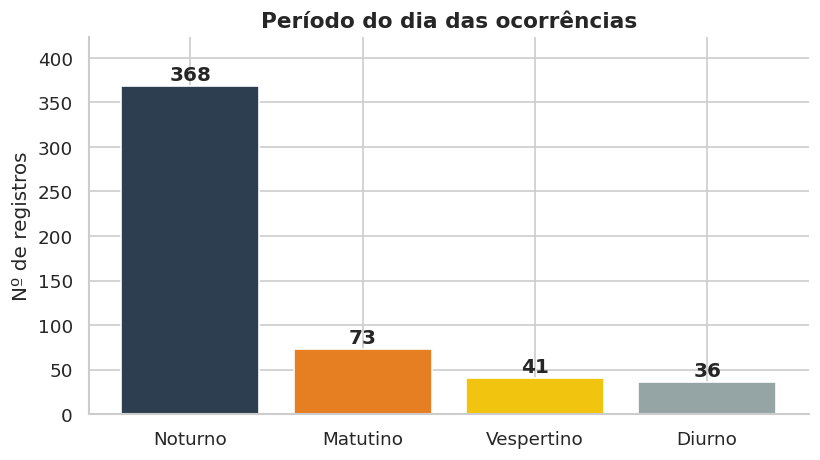

In [13]:
col_periodo = 'PERÍODO (matutino, vespertino e noturno)'
periodo = base[base[col_periodo] != 'N.I.'][col_periodo].value_counts()

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(periodo.index, periodo.values,
              color=['#2c3e50', '#e67e22', '#f1c40f', '#95a5a6'][:len(periodo)],
              edgecolor='white')
for bar, val in zip(bars, periodo.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, str(val),
            ha='center', va='bottom', fontweight='bold')
ax.set_title('Período do dia das ocorrências', fontsize=13, fontweight='bold')
ax.set_ylabel('Nº de registros')
ax.set_ylim(0, periodo.max() * 1.15)
sns.despine()
plt.tight_layout()
plt.show()

## 8. Identidade de gênero e orientação sexual

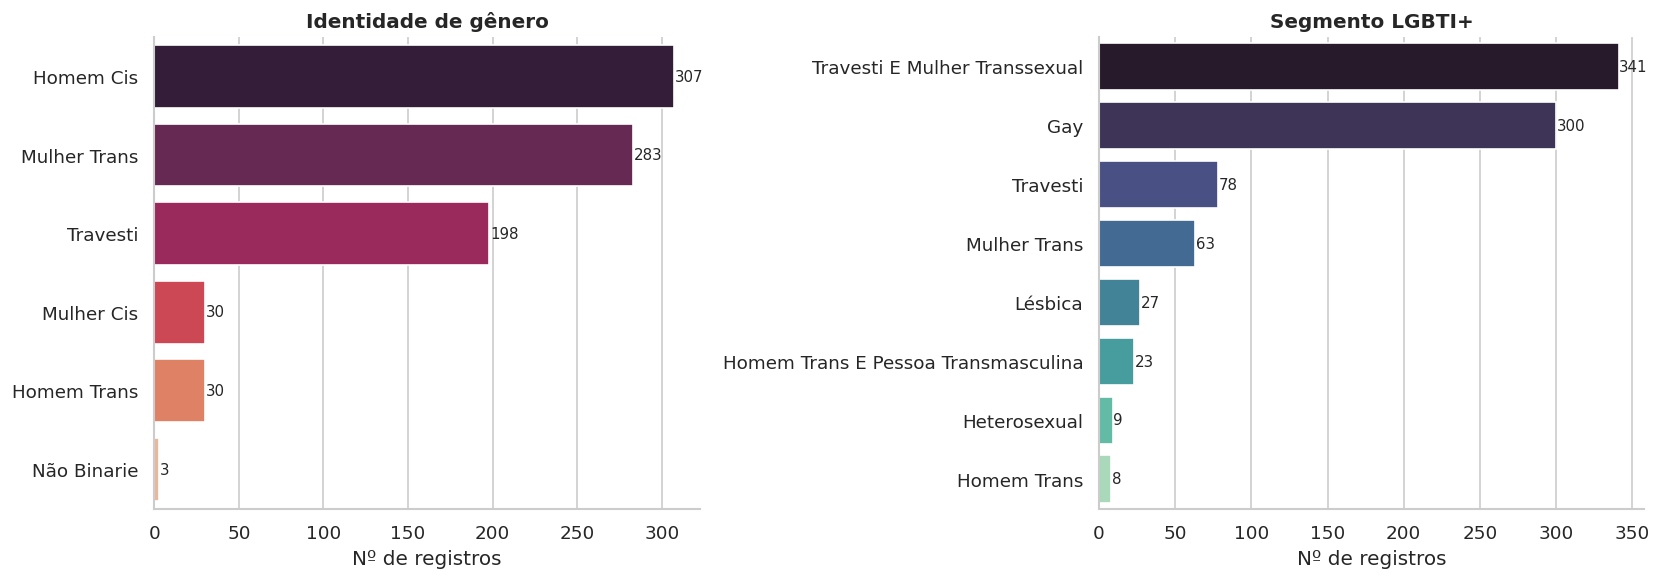

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Identidade de gênero
ig = base[base['IDENTIDADE DE GÊNERO'] != 'N.I.']['IDENTIDADE DE GÊNERO'].value_counts()
sns.barplot(x=ig.values, y=ig.index, palette='rocket', ax=axes[0])
for i, v in enumerate(ig.values):
    axes[0].text(v + 0.5, i, str(v), va='center', fontsize=9)
axes[0].set_title('Identidade de gênero', fontweight='bold')
axes[0].set_xlabel('Nº de registros')
axes[0].set_ylabel('')

# Segmento
seg = base[base['SEGMENTO'] != 'N.I.']['SEGMENTO'].value_counts().head(8)
sns.barplot(x=seg.values, y=seg.index, palette='mako', ax=axes[1])
for i, v in enumerate(seg.values):
    axes[1].text(v + 0.5, i, str(v), va='center', fontsize=9)
axes[1].set_title('Segmento LGBTI+', fontweight='bold')
axes[1].set_xlabel('Nº de registros')
axes[1].set_ylabel('')

sns.despine()
plt.tight_layout()
plt.show()

## 9. Raça/Etnia

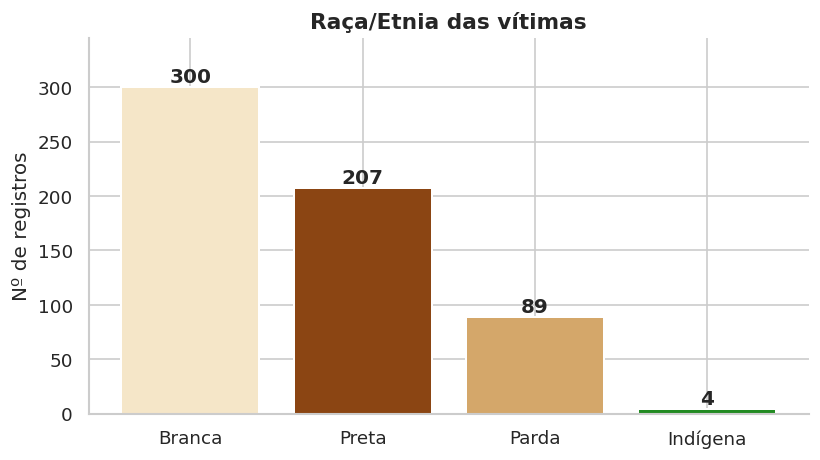

In [15]:
raca = base[base['RAÇA/ETNIA'] != 'N.I.']['RAÇA/ETNIA'].value_counts()

fig, ax = plt.subplots(figsize=(7, 4))
cores_raca = ['#f5e6c8', '#8B4513', '#d4a76a', '#228B22', '#4a4a4a']
bars = ax.bar(raca.index, raca.values, color=cores_raca[:len(raca)], edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, raca.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, str(val),
            ha='center', va='bottom', fontweight='bold')
ax.set_title('Raça/Etnia das vítimas', fontsize=13, fontweight='bold')
ax.set_ylabel('Nº de registros')
ax.set_ylim(0, raca.max() * 1.15)
sns.despine()
plt.tight_layout()
plt.show()

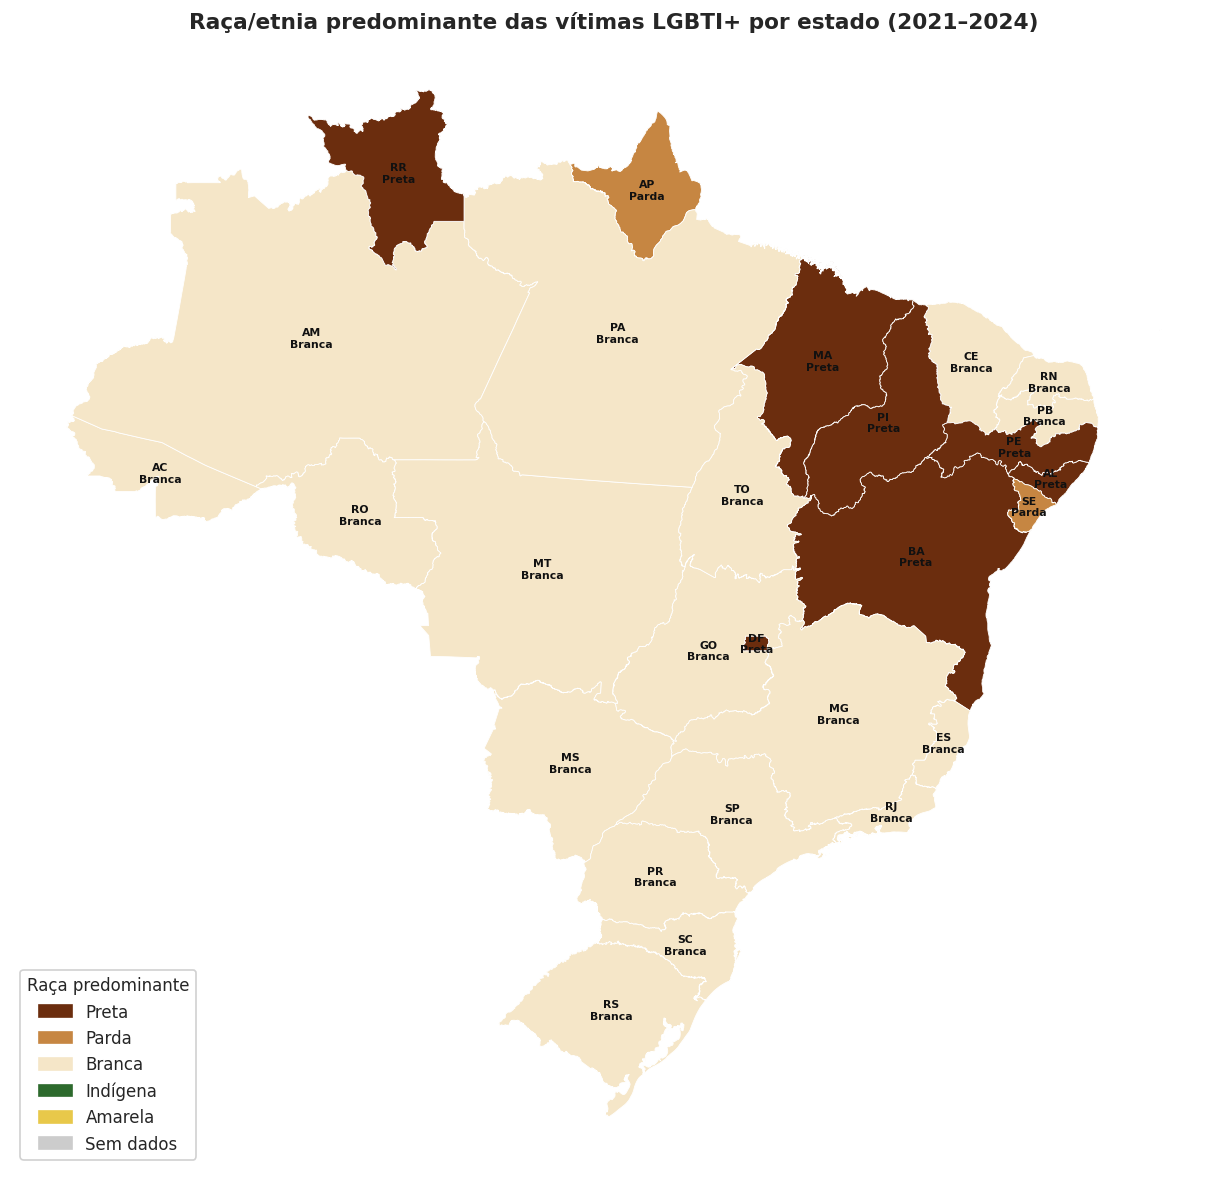

In [12]:
fig, ax = plt.subplots(figsize=(12, 10))

gdf['cor_raca'] = gdf['raca_predominante'].map(cores_raca).fillna('#cccccc')
gdf.plot(color=gdf['cor_raca'], linewidth=0.5, edgecolor='white', ax=ax)
ax.set_title('Raça/etnia predominante das vítimas LGBTI+ por estado (2021–2024)',
             fontweight='bold', fontsize=13)
ax.axis('off')

for _, row in gdf.iterrows():
    if row.geometry:
        x, y = row.geometry.centroid.x, row.geometry.centroid.y
        label = row['raca_predominante'] if pd.notna(row['raca_predominante']) else '?'
        ax.annotate(f"{row['sigla']}\n{label}",
                    xy=(x, y), ha='center', va='center',
                    fontsize=6.5, color='#111111', fontweight='bold')

patches = [mpatches.Patch(color=c, label=r) for r, c in cores_raca.items()]
patches.append(mpatches.Patch(color='#cccccc', label='Sem dados'))
ax.legend(handles=patches, loc='lower left', fontsize=10,
          title='Raça predominante', title_fontsize=10, framealpha=0.9)

plt.tight_layout()
plt.show()

## 10. Distribuição de idade

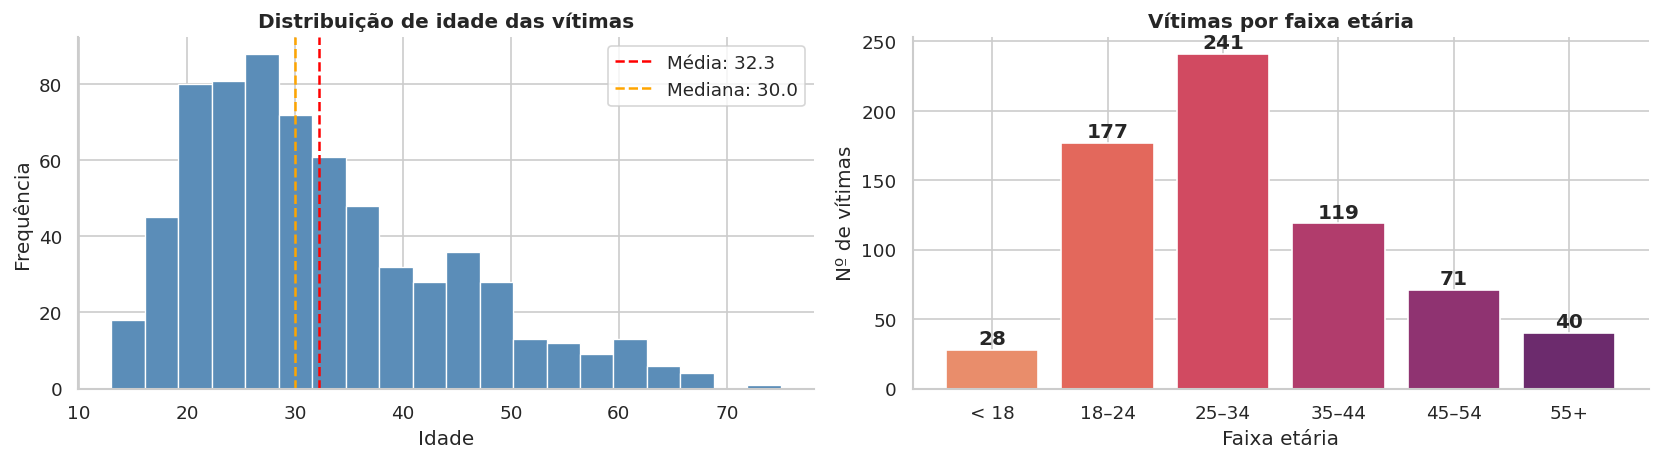

Média de idade: 32.3 anos
Mediana: 30.0 anos
Mínima: 13 | Máxima: 75


In [16]:
idades = base['IDADE_NUM'].dropna()
idades = idades[(idades >= 10) & (idades <= 80)]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histograma
axes[0].hist(idades, bins=20, color='#5b8db8', edgecolor='white', linewidth=0.8)
axes[0].axvline(idades.mean(), color='red', linestyle='--', label=f'Média: {idades.mean():.1f}')
axes[0].axvline(idades.median(), color='orange', linestyle='--', label=f'Mediana: {idades.median():.1f}')
axes[0].set_title('Distribuição de idade das vítimas', fontweight='bold')
axes[0].set_xlabel('Idade')
axes[0].set_ylabel('Frequência')
axes[0].legend()

# Faixas etárias
bins = [0, 17, 24, 34, 44, 54, 100]
labels = ['< 18', '18–24', '25–34', '35–44', '45–54', '55+']
base['FAIXA_ETARIA'] = pd.cut(base['IDADE_NUM'], bins=bins, labels=labels)
faixas = base['FAIXA_ETARIA'].value_counts().sort_index()
axes[1].bar(faixas.index.astype(str), faixas.values, color=sns.color_palette('flare', len(faixas)), edgecolor='white')
for i, v in enumerate(faixas.values):
    axes[1].text(i, v + 1, str(v), ha='center', va='bottom', fontweight='bold')
axes[1].set_title('Vítimas por faixa etária', fontweight='bold')
axes[1].set_xlabel('Faixa etária')
axes[1].set_ylabel('Nº de vítimas')

sns.despine()
plt.tight_layout()
plt.show()

print(f'Média de idade: {idades.mean():.1f} anos')
print(f'Mediana: {idades.median():.1f} anos')
print(f'Mínima: {int(idades.min())} | Máxima: {int(idades.max())}')

## 11. Tipificação (causa jurídica)

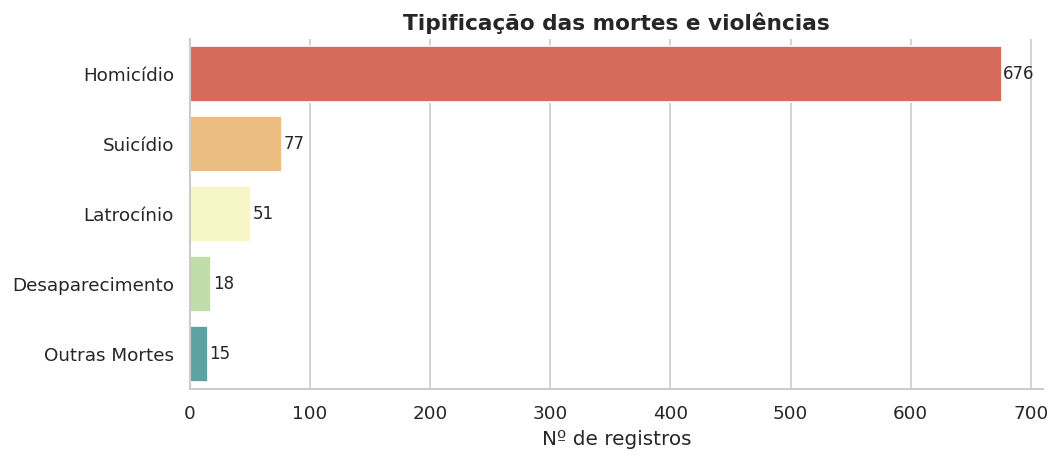

In [17]:
tip = base[base['TIPIFICAÇÃO'] != 'N.I.']['TIPIFICAÇÃO'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(x=tip.values, y=tip.index, palette='Spectral', ax=ax)
for i, v in enumerate(tip.values):
    ax.text(v + 1, i, str(v), va='center', fontsize=10)
ax.set_title('Tipificação das mortes e violências', fontsize=13, fontweight='bold')
ax.set_xlabel('Nº de registros')
ax.set_ylabel('')
sns.despine()
plt.tight_layout()
plt.show()

## 12. Profissão/Ocupação (Top 10)

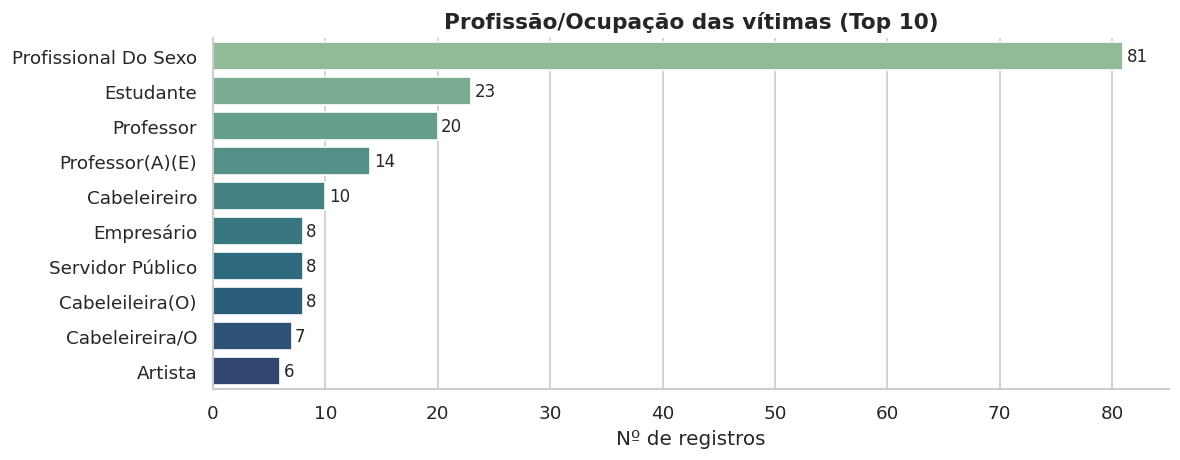

In [18]:
prof = base[base['PROFISSÃO/OCUPAÇÃO DA VÍTIMA'] != 'N.I.']['PROFISSÃO/OCUPAÇÃO DA VÍTIMA'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(x=prof.values, y=prof.index, palette='crest', ax=ax)
for i, v in enumerate(prof.values):
    ax.text(v + 0.3, i, str(v), va='center', fontsize=10)
ax.set_title('Profissão/Ocupação das vítimas (Top 10)', fontsize=13, fontweight='bold')
ax.set_xlabel('Nº de registros')
ax.set_ylabel('')
sns.despine()
plt.tight_layout()
plt.show()

## 13. Sazonalidade — ocorrências por mês

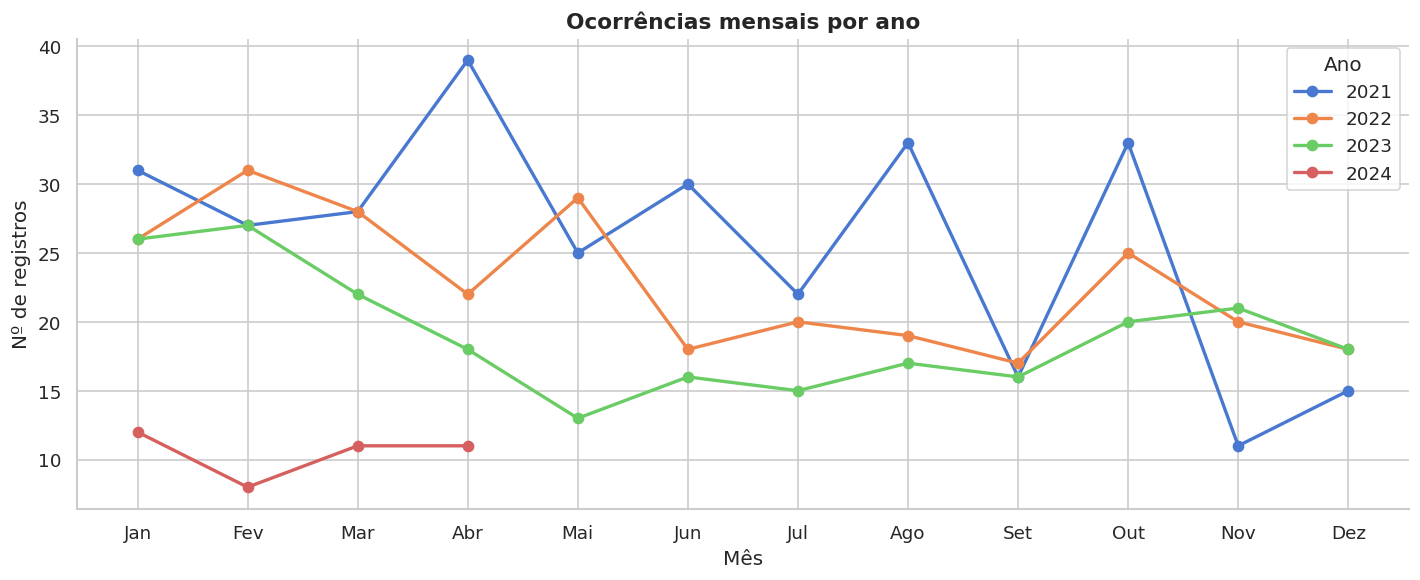

In [19]:
meses_nomes = ['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez']
sazon = base.groupby(['ANO', 'MÊS_NUM']).size().reset_index(name='count')
sazon = sazon.dropna(subset=['MÊS_NUM'])
sazon['MÊS_NUM'] = sazon['MÊS_NUM'].astype(int)

fig, ax = plt.subplots(figsize=(12, 5))
for ano, grp in sazon.groupby('ANO'):
    ax.plot(grp['MÊS_NUM'], grp['count'], marker='o', label=str(ano), linewidth=2)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(meses_nomes)
ax.set_title('Ocorrências mensais por ano', fontsize=13, fontweight='bold')
ax.set_xlabel('Mês')
ax.set_ylabel('Nº de registros')
ax.legend(title='Ano')
sns.despine()
plt.tight_layout()
plt.show()

## 14. Cruzamentos

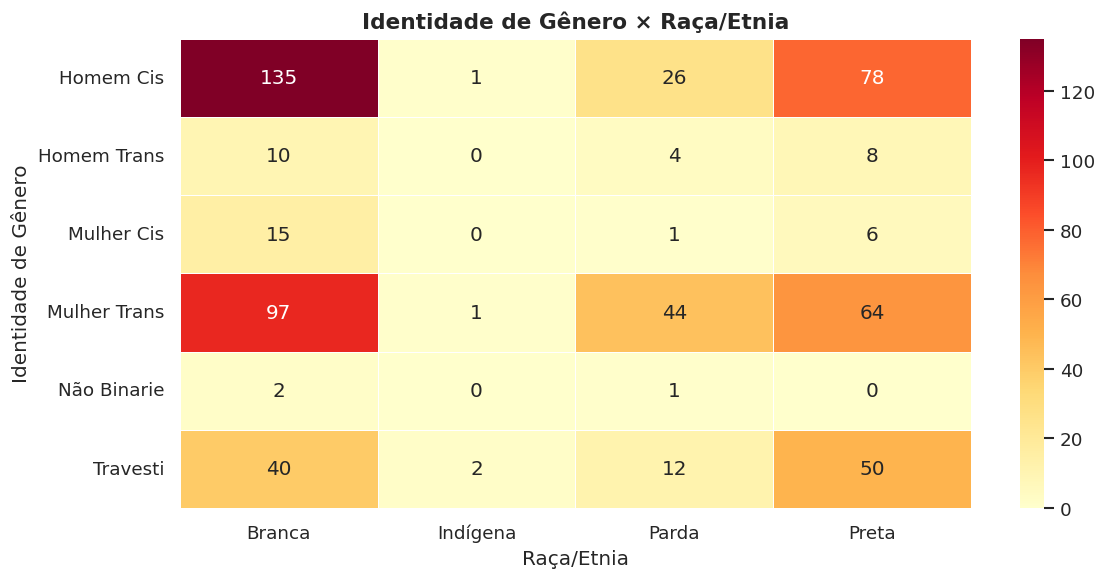

In [20]:
# Identidade de gênero x Raça/Etnia
cross = pd.crosstab(
    base[base['IDENTIDADE DE GÊNERO'] != 'N.I.']['IDENTIDADE DE GÊNERO'],
    base[base['RAÇA/ETNIA'] != 'N.I.']['RAÇA/ETNIA']
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(cross, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5, ax=ax)
ax.set_title('Identidade de Gênero × Raça/Etnia', fontsize=13, fontweight='bold')
ax.set_xlabel('Raça/Etnia')
ax.set_ylabel('Identidade de Gênero')
plt.tight_layout()
plt.show()

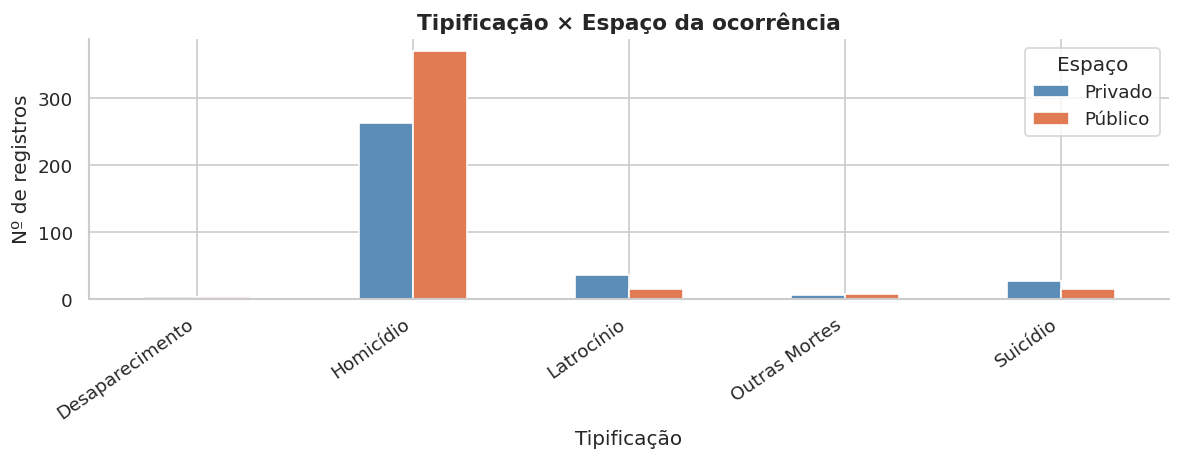

In [21]:
# Tipificação x Espaço
cross2 = pd.crosstab(
    base[base['TIPIFICAÇÃO'] != 'N.I.']['TIPIFICAÇÃO'].replace({'Homicidio':'Homicídio','Suicidio':'Suicídio'}),
    base[base['ESPAÇO'].isin(['Público','Privado'])]['ESPAÇO']
).head(8)

cross2.plot(kind='bar', figsize=(10, 4), color=['#5b8db8','#e07b54'], edgecolor='white')
plt.title('Tipificação × Espaço da ocorrência', fontsize=13, fontweight='bold')
plt.xlabel('Tipificação')
plt.ylabel('Nº de registros')
plt.xticks(rotation=35, ha='right')
plt.legend(title='Espaço')
sns.despine()
plt.tight_layout()
plt.show()